# NB03: Construcción del supra-grafo heterogéneo TCGA-HNSC

**Fase 3** del pipeline SupraGraphNet. Transforma las matrices de expresión preprocesadas en un único objeto `HeteroData` de PyTorch Geometric que integra dos tipos de nodos (590 isomiRs miRNA y 5.305 isoformas mRNA) y dos tipos de aristas (co-expresión isomiR↔isomiR y represión isomiR→isoforma vía TargetScan). El grafo incluye los 474 pacientes de forma conjunta.

**Entradas (NB02):** `mirna_matrix_tumor.pt`, `isoforma_matrix_tumor.pt`, `patient_barcodes_tumor.txt`, `selected_mirna_ids.txt`, `selected_isoforma_ids.txt`, `survival_targets_final.csv`  
**Entradas externas:** `mature.fa` (miRBase), `Predicted_Targets_Context_Scores...txt` (TargetScan), `HNSC.rnaseqv2...data.txt` (TCGA RSEM genes)  
**Salida principal:** `hetero_graph_all.pt`

## 0. Setup y rutas

Montaje de Google Drive, instalación de dependencias e importación de librerías del módulo `hnsc_graph`. Se verifican los nueve ficheros de entrada necesarios.

In [ ]:
from google.colab import drive
import os, sys
drive.mount('/content/drive')
carpeta_proyecto = '/content/drive/MyDrive/TFM'
os.chdir(carpeta_proyecto)
sys.path.append(carpeta_proyecto)
print('Directorio de trabajo:', os.getcwd())

Mounted at /content/drive
Directorio de trabajo: /content/drive/MyDrive/TFM


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

project_root = Path.cwd()
sys.path.append(str(project_root / 'src'))

from hnsc_graph.preprocessing import setup_logging
from hnsc_graph.graph_construction import (
    build_mimat_name_maps,
    build_mirna_isoform_edges,
    build_mirna_mirna_edges,
    HeteroGraphConfig,
    HeteroGraphBuilder,
)
setup_logging()
sns.set(style='whitegrid')

BASE_DIR      = Path(r'/content/drive/MyDrive/TFM/data')
PROCESSED_DIR = BASE_DIR / 'processed_hnsc'

# ── Outputs de NB02 ───────────────────────────────────────────────────
MIRNA_PT       = PROCESSED_DIR / 'mirna_matrix_tumor.pt'
ISOFORMA_PT    = PROCESSED_DIR / 'isoforma_matrix_tumor.pt'
BARCODES_FILE  = PROCESSED_DIR / 'patient_barcodes_tumor.txt'
MIRNA_IDS_FILE = PROCESSED_DIR / 'selected_mirna_ids.txt'
ISO_IDS_FILE   = PROCESSED_DIR / 'selected_isoforma_ids.txt'
TARGETS_FILE   = PROCESSED_DIR / 'survival_targets_final.csv'

# ── Bases de datos externas ───────────────────────────────────────────
MATURE_FA_PATH    = BASE_DIR / 'mature.fa'
TARGETSCAN_PATH   = BASE_DIR / 'Predicted_Targets_Context_Scores.default_predictions.txt'
GENES_ISOFORM_MAP = BASE_DIR / 'HNSC.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes__data.data.txt'

for p in [MIRNA_PT, ISOFORMA_PT, BARCODES_FILE, MIRNA_IDS_FILE,
          ISO_IDS_FILE, TARGETS_FILE, MATURE_FA_PATH,
          TARGETSCAN_PATH, GENES_ISOFORM_MAP]:
    print(f"{'OK' if p.exists() else 'FALTA'}  {p.name}")

OK — mirna_matrix_tumor.pt
OK — isoforma_matrix_tumor.pt
OK — patient_barcodes_tumor.txt
OK — selected_mirna_ids.txt
OK — selected_isoforma_ids.txt
OK — survival_targets_final.csv
OK — mature.fa
OK — Predicted_Targets_Context_Scores.default_predictions.txt
OK — HNSC.rnaseqv2__illuminahiseq_rnaseqv2__unc_edu__Level_3__RSEM_genes__data.data.txt


## Paso 1: Carga de matrices de expresión y targets

Lee los tensores PyTorch de NB02, reconstruye los DataFrames con índices de barcode y calcula la intersección final de pacientes con datos completos en ambas ómicas y targets. Resultado: **474 pacientes** (198 fallecidos, 276 censurados).

In [ ]:

# CARGA DE DATOS  desde outputs de NB02


# ── Barcodes e IDs de features ───────────────────────────────────────
with open(BARCODES_FILE) as f:
    barcodes_tumor = [l.strip() for l in f if l.strip()]

with open(MIRNA_IDS_FILE) as f:
    mirna_ids = [l.strip() for l in f if l.strip()]

with open(ISO_IDS_FILE) as f:
    isoforma_ids = [l.strip() for l in f if l.strip()]

# ── Tensores de expresión → DataFrames [muestras x features] ─────────
mirna_tensor    = torch.load(MIRNA_PT)      # [474 x 590]
isoforma_tensor = torch.load(ISOFORMA_PT)   # [474 x 5305]

mirna_expr   = pd.DataFrame(
    mirna_tensor.numpy(),
    index=barcodes_tumor,
    columns=mirna_ids
)
isoform_expr = pd.DataFrame(
    isoforma_tensor.numpy(),
    index=barcodes_tumor,
    columns=isoforma_ids
)

# ── Targets de supervivencia ──────────────────────────────────────────
targets_df = pd.read_csv(TARGETS_FILE, index_col=0)

# ── Alinear cohorte (por si acaso) ────────────────────────────────────
common = sorted(set(mirna_expr.index) & set(isoform_expr.index) & set(targets_df.index))
mirna_expr   = mirna_expr.loc[common]
isoform_expr = isoform_expr.loc[common]
targets_df   = targets_df.loc[common]

# ── Eliminar pacientes con OS.time NaN ───────────────────────────────
mask_valid = targets_df['OS.time'].notna()
n_drop = (~mask_valid).sum()
if n_drop > 0:
    print(f"Eliminados {n_drop} pacientes con OS.time NaN")
    targets_df   = targets_df[mask_valid]
    mirna_expr   = mirna_expr.loc[targets_df.index]
    isoform_expr = isoform_expr.loc[targets_df.index]

print(f"miRNA        : {mirna_expr.shape}   (pacientes x MIMATs)")
print(f"Isoformas    : {isoform_expr.shape} (pacientes x isoformas)")
print(f"Targets      : {targets_df.shape}")
print()
print(f"Fallecidos  (OS=1): {int((targets_df['OS']==1).sum())}")
print(f"Censurados  (OS=0): {int((targets_df['OS']==0).sum())}")
print(f"Cohorte final      : {len(common)} pacientes")

miRNA        : (474, 590)   (pacientes x MIMATs)
Isoformas    : (474, 5305) (pacientes x isoformas)
Targets      : (474, 6)

Fallecidos  (OS=1): 198
Censurados  (OS=0): 276
Cohorte final      : 474 pacientes


## Paso 2: Mapeo MIMAT → nombre miRNA (miRBase)

Parsea `mature.fa` de miRBase para obtener el diccionario MIMAT → nombre canónico (p.ej., MIMAT0000765 → hsa-miR-335-5p). Cobertura: **583 de 590 MIMATs** (98.8%). Los 7 sin mapeo no participarán en las aristas de represión de TargetScan.

In [ ]:

# PASO 1: Mapeo MIMAT → nombre miRNA via miRBase (mature.fa)


mimat_to_name, name_to_mimat = build_mimat_name_maps(MATURE_FA_PATH)

our_mimats = mirna_expr.columns.tolist()
cobertura  = [m for m in our_mimats if m in mimat_to_name]
print(f"isomiRs en nuestra matriz        : {len(our_mimats)}")
print(f"Con nombre miRBase asignado      : {len(cobertura)} ({len(cobertura)/len(our_mimats)*100:.1f}%)")
print(f"Sin nombre (sin mapeo TargetScan): {len(our_mimats)-len(cobertura)}")
print()
print("Ejemplos de mapeo:")
for m in cobertura[:5]:
    print(f"  {m} → {mimat_to_name[m]}")

miRBase: 2656 entradas hsa cargadas


isomiRs en nuestra matriz        : 590
Con nombre miRBase asignado      : 583 (98.8%)
Sin nombre (sin mapeo TargetScan): 7

Ejemplos de mapeo:
  MIMAT0000765 → hsa-miR-335-5p
  MIMAT0000764 → hsa-miR-339-5p
  MIMAT0000761 → hsa-miR-324-5p
  MIMAT0000760 → hsa-miR-331-3p
  MIMAT0000763 → hsa-miR-338-3p


## Paso 3: Diccionario isoforma → gen (TCGA RSEM genes)

Construye el mapa UCSC transcript ID → gene symbol a partir del fichero RSEM de genes TCGA, necesario para conectar las dianas de TargetScan (en genes) con los nodos isoforma del grafo. Cobertura: **5.230 de 5.305 isoformas** (98.6%).

In [ ]:

# PASO 2: Diccionario isoforma → gen desde archivo genes TCGA


print('Construyendo diccionario isoforma → gen...')
try:
    df_bruto = pd.read_csv(GENES_ISOFORM_MAP, sep='\t', low_memory=False)

    # Detectar columna transcript_id
    if 'transcript_id' in str(df_bruto.iloc[0].values):
        idx_t = list(df_bruto.iloc[0].values).index('transcript_id')
        dic_df = df_bruto.iloc[1:, [0, idx_t]].copy()
    else:
        dic_df = df_bruto.iloc[1:, [0, 3]].copy()

    dic_df.columns = ['gene_completo', 'transcript_id']
    dic_df['gene_symbol'] = dic_df['gene_completo'].astype(str).apply(
        lambda x: x.split('|')[0] if '|' in x else x)
    dic_df = dic_df[dic_df['gene_symbol'] != '?']

    # Separar isoformas múltiples por coma
    dic_df['transcript_id'] = dic_df['transcript_id'].astype(str).str.split(',')
    dic_df = dic_df.explode('transcript_id')
    dic_df['transcript_id'] = dic_df['transcript_id'].str.strip()
    dic_df = dic_df.drop_duplicates(subset=['transcript_id'])

    isoform_to_gene = dict(zip(dic_df['transcript_id'], dic_df['gene_symbol']))
    print(f'Diccionario: {len(isoform_to_gene)} isoformas mapeadas a genes')

    our_isoforms    = isoform_expr.columns.tolist()
    cobertura_iso   = [i for i in our_isoforms if i in isoform_to_gene]
    print(f'Isoformas nuestras con gen asignado: {len(cobertura_iso)} / {len(our_isoforms)} '
          f'({len(cobertura_iso)/len(our_isoforms)*100:.1f}%)')

except Exception as e:
    print(f'Error: {e}')
    isoform_to_gene = {}

Construyendo diccionario isoforma → gen...
Diccionario: 67329 isoformas mapeadas a genes
Isoformas nuestras con gen asignado: 5230 / 5305 (98.6%)


## Paso 4: Aristas de co-expresión isomiR ↔ isomiR

Calcula la correlación de Spearman entre los perfiles de expresión de todos los pares de MIMATs sobre los 474 pacientes. Se retienen los pares con |r| ≥ 0.55. Las aristas se añaden en ambas direcciones para permitir paso de mensajes bidireccional. Resultado: **2.511 pares** (5.022 aristas dirigidas), correlación media 0.64, grado medio 8.5; **179 isomiRs aislados** sin co-expresión por encima del umbral.

In [ ]:

# PASO 3: Aristas isomiR ↔ isomiR por correlación de expresión


mirna_mirna_edges = build_mirna_mirna_edges(
    mirna_expr  = mirna_expr,
    r_threshold = 0.55,
    method      = 'spearman',
)

print(f'Pares isomiR↔isomiR con |r|>=0.55 : {len(mirna_mirna_edges)}')
print(f'isomiRs con al menos una arista   : '
      f"{len(set(mirna_mirna_edges['mirna_src']) | set(mirna_mirna_edges['mirna_dst']))}")
print(f'isomiRs aislados                  : '
      f"{len(mirna_expr.columns) - len(set(mirna_mirna_edges['mirna_src']) | set(mirna_mirna_edges['mirna_dst']))}")
print()
print('Estadísticos correlación:')
print(mirna_mirna_edges['correlation'].describe())

mirna_mirna_edges.to_csv(PROCESSED_DIR / 'mirna_mirna_edges.csv', index=False)
print('\nAristas isomiR↔isomiR guardadas.')

Calculando correlaciones spearman entre 590 isomiRs sobre 474 pacientes...
Aristas isomiR↔isomiR: 2511 pares con |r|>=0.55


Pares isomiR↔isomiR con |r|>=0.55 : 2511
isomiRs con al menos una arista   : 411
isomiRs aislados                  : 179

Estadísticos correlación:
count    2511.000000
mean        0.642034
std         0.147802
min        -0.678451
25%         0.583807
50%         0.629209
75%         0.702185
max         1.000000
Name: correlation, dtype: float64

Aristas isomiR↔isomiR guardadas.


### EDA: aristas isomiR ↔ isomiR

Tres paneles: distribución de correlaciones Spearman, distribución de grado por isomiR y top 20 isomiRs más conectados (etiquetados con nombre canónico miRBase).

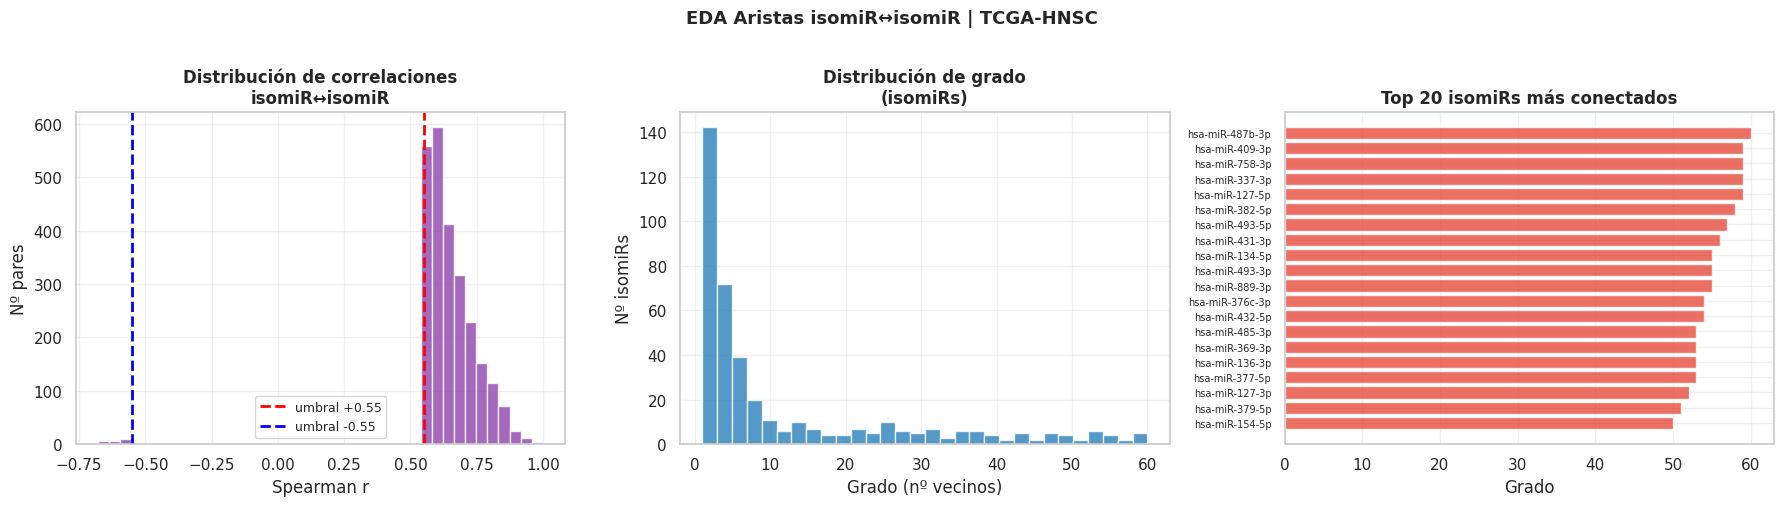

Grado medio  : 12.2
Grado máximo : 60
isomiRs aislados: 179


In [ ]:
# EDA  aristas isomiR↔isomiR


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [0] Distribución de correlaciones
axes[0].hist(mirna_mirna_edges['correlation'], bins=40,
             color='#8e44ad', alpha=0.8, edgecolor='white')
axes[0].axvline(0.55,  color='red',  linestyle='--', linewidth=2, label='umbral +0.55')
axes[0].axvline(-0.55, color='blue', linestyle='--', linewidth=2, label='umbral -0.55')
axes[0].set_title('Distribución de correlaciones\nisomiR↔isomiR', fontweight='bold')
axes[0].set_xlabel('Spearman r')
axes[0].set_ylabel('Nº pares')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# [1] Grado de cada isomiR
grado = Counter(
    mirna_mirna_edges['mirna_src'].tolist() +
    mirna_mirna_edges['mirna_dst'].tolist()
)
grados_vals = list(grado.values())
axes[1].hist(grados_vals, bins=30, color='#2980b9', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribución de grado\n(isomiRs)', fontweight='bold')
axes[1].set_xlabel('Grado (nº vecinos)')
axes[1].set_ylabel('Nº isomiRs')
axes[1].grid(alpha=0.3)

# [2] Top 20 isomiRs más conectados
top20 = sorted(grado.items(), key=lambda x: x[1], reverse=True)[:20]
names20, degs20 = zip(*top20)
axes[2].barh(range(20), list(degs20)[::-1], color='#e74c3c', alpha=0.8)
axes[2].set_yticks(range(20))
axes[2].set_yticklabels(
    [mimat_to_name.get(m, m) for m in names20][::-1], fontsize=7)
axes[2].set_title('Top 20 isomiRs más conectados', fontweight='bold')
axes[2].set_xlabel('Grado')
axes[2].grid(alpha=0.3)

plt.suptitle('EDA Aristas isomiR↔isomiR | TCGA-HNSC', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Grado medio  : {np.mean(grados_vals):.1f}')
print(f'Grado máximo : {max(grados_vals)}')
print(f'isomiRs aislados: {len(mirna_expr.columns) - len(grado)}')

## Paso 5: Aristas de represión isomiR → isoforma (TargetScan)

Cadena de mapeo en tres pasos: MIMAT → nombre miRNA (miRBase) → gen diana con context++ score < 0 (TargetScan, 59.291 interacciones hsa) → isoformas del gen (diccionario UCSC-gen). Resultado: **58.935 aristas** de represión, que conectan 226 isomiRs con 3.685 isoformas reguladas. Las 1.620 isoformas restantes no tienen ningún regulador anotado en TargetScan dentro de la cohorte.

In [ ]:

# Aristas miRNA → isoforma via TargetScan


mirna_isoform_edges = build_mirna_isoform_edges(
    targetscan_path         = TARGETSCAN_PATH,
    name_to_mimat           = name_to_mimat,
    isoform_to_gene         = isoform_to_gene,
    valid_mimats            = mirna_expr.columns.tolist(),
    valid_isoforms          = isoform_expr.columns.tolist(),
    context_score_threshold = 0.0,  # solo scores negativos (interacciones reales)
)

print(f'Aristas isomiR→isoforma          : {len(mirna_isoform_edges)}')
print(f'isomiRs con dianas               : {mirna_isoform_edges["mirna_id"].nunique()}')
print(f'Isoformas con reguladores        : {mirna_isoform_edges["isoform_id"].nunique()}')
print(f'Isoformas sin reguladores        : '
      f"{len(isoform_expr.columns) - mirna_isoform_edges['isoform_id'].nunique()}")
print()
print('Estadísticos context++ score:')
print(mirna_isoform_edges['context_score'].describe())

mirna_isoform_edges.to_csv(PROCESSED_DIR / 'mirna_isoform_edges.csv', index=False)
print('\nAristas isomiR→isoforma guardadas.')

TargetScan: 59291 interacciones hsa para nuestros genes
Tras mapear MIMAT y filtrar a nuestros isomiRs: 43412
Aristas isomiR→isoforma finales: 58935 | isomiRs: 226 | isoformas: 3685


Aristas isomiR→isoforma          : 58935
isomiRs con dianas               : 226
Isoformas con reguladores        : 3685
Isoformas sin reguladores        : 1620

Estadísticos context++ score:
count    58935.000000
mean        -0.180519
std          0.126189
min         -1.109000
25%         -0.254000
50%         -0.166000
75%         -0.080000
max         -0.010000
Name: context_score, dtype: float64

Aristas isomiR→isoforma guardadas.


### EDA: aristas isomiR → isoforma

Dos paneles: distribución del context++ score (todos negativos, más negativo = represión más fuerte) y distribución del grado de isoformas (nº de isomiRs reguladores por isoforma).

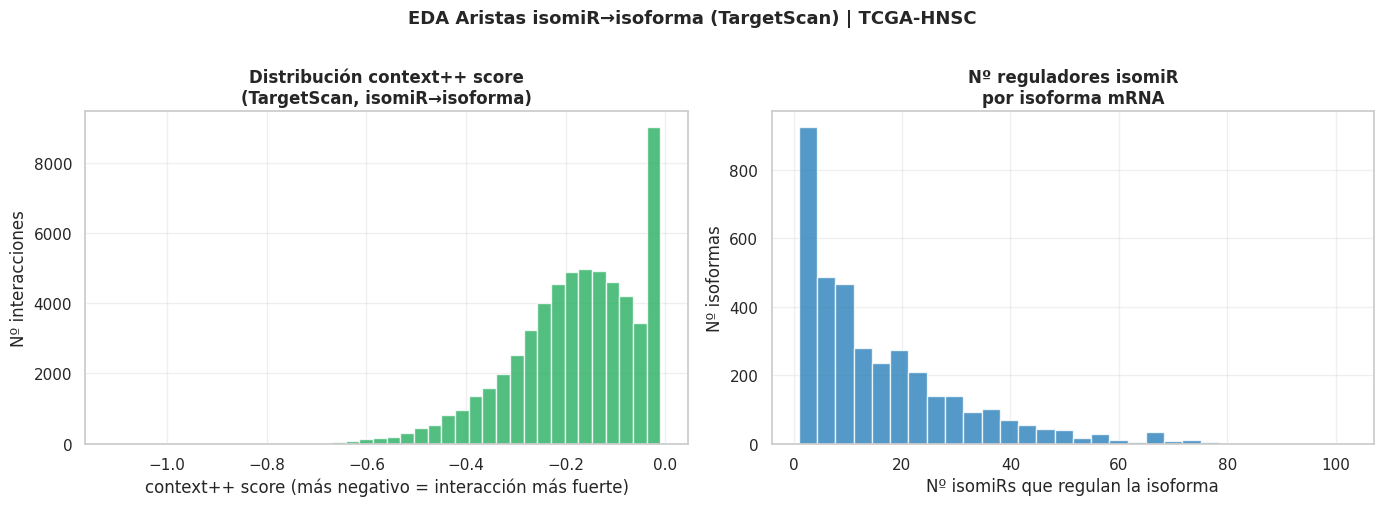

In [ ]:
# EDA aristas isomiR→isoforma


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [0] Distribución context++ score
axes[0].hist(mirna_isoform_edges['context_score'], bins=40,
             color='#27ae60', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución context++ score\n(TargetScan, isomiR→isoforma)',
                  fontweight='bold')
axes[0].set_xlabel('context++ score (más negativo = interacción más fuerte)')
axes[0].set_ylabel('Nº interacciones')
axes[0].grid(alpha=0.3)

# [1] Grado de isoformas (nº reguladores por isoforma)
grado_iso = mirna_isoform_edges.groupby('isoform_id').size()
axes[1].hist(grado_iso.values, bins=30, color='#2980b9', alpha=0.8, edgecolor='white')
axes[1].set_title('Nº reguladores isomiR\npor isoforma mRNA', fontweight='bold')
axes[1].set_xlabel('Nº isomiRs que regulan la isoforma')
axes[1].set_ylabel('Nº isoformas')
axes[1].grid(alpha=0.3)

plt.suptitle('EDA Aristas isomiR→isoforma (TargetScan) | TCGA-HNSC',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Paso 6: Construcción del grafo heterogéneo único

Ensambla el objeto `HeteroData` con los dos tipos de nodos, los dos tipos de aristas y los targets de supervivencia. El grafo incluye a los **474 pacientes de forma conjunta** (198 fallecidos + 276 censurados): la Cox Partial Likelihood Loss necesita ver ambos grupos para calcular el riesgo relativo correctamente; separar en subgrafos sería incorrecto.

Features nodales: cada nodo almacena su vector de expresión a lo largo de los 474 pacientes tensor `[n_nodos × n_pacientes]`.

In [ ]:
#  Construcción del grafo heterogéneo único


print(f'Pacientes totales : {len(targets_df)}')
print(f'  Fallecidos (OS=1): {int((targets_df["OS"]==1).sum())}')
print(f'  Censurados (OS=0): {int((targets_df["OS"]==0).sum())}')
print()

graph_cfg = HeteroGraphConfig()
builder   = HeteroGraphBuilder(graph_cfg)

print('Construyendo grafo heterogéneo único...')
graph = builder.build(
    mirna_expr          = mirna_expr,
    isoform_expr        = isoform_expr,
    mirna_mirna_edges   = mirna_mirna_edges,
    mirna_isoform_edges = mirna_isoform_edges,
    targets             = targets_df,
)

print()
print(f'  isomiRs (nodos)         : {graph["mirna"].x.shape}   [n_mirna x n_pacientes]')
print(f'  isoformas (nodos)       : {graph["isoform"].x.shape} [n_isoformas x n_pacientes]')
print(f'  aristas mirna↔mirna     : {graph[("mirna","coexpresses","mirna")].edge_index.shape[1]//2} pares')
print(f'  aristas mirna→isoforma  : {graph[("mirna","represses","isoform")].edge_index.shape[1]}')
print(f'  os_time                 : {graph.os_time.shape}')
print(f'  fallecidos              : {int(graph.os_event.sum().item())}')
print(f'  censurados              : {int((graph.os_event==0).sum().item())}')

Pacientes en el grafo: 474
  Fallecidos (OS=1): 198 | Censurados (OS=0): 276
Aristas isomiR↔isomiR: 5022 dirigidas (2511 pares)


Pacientes totales : 474
  Fallecidos (OS=1): 198
  Censurados (OS=0): 276

Construyendo grafo heterogéneo único...


Aristas isomiR→isoforma: 58935
Grafo construido: 590 isomiRs | 5305 isoformas | 474 pacientes | aristas mm=2511 | aristas mi=58935



  isomiRs (nodos)         : torch.Size([590, 474])   [n_mirna x n_pacientes]
  isoformas (nodos)       : torch.Size([5305, 474]) [n_isoformas x n_pacientes]
  aristas mirna↔mirna     : 2511 pares
  aristas mirna→isoforma  : 58935
  os_time                 : torch.Size([474])
  fallecidos              : 198
  censurados              : 276


## Paso 7: Health check de integridad

Verifica automáticamente: ausencia de NaN en features nodales y en `os_time`, consistencia de dimensiones y que todos los índices de aristas están dentro de rango. También reporta el grado medio por tipo de arista y los nodos aislados en cada tipo.

In [ ]:
# HEALTH CHECK  verificación de integridad del grafo


n_mirna   = graph['mirna'].x.shape[0]
n_isoform = graph['isoform'].x.shape[0]
n_pats    = graph['mirna'].x.shape[1]

ei_mm = graph[('mirna','coexpresses','mirna')].edge_index
ei_mi = graph[('mirna','represses','isoform')].edge_index

grado_mirna_mm  = torch.bincount(ei_mm[0], minlength=n_mirna)
grado_mirna_mi  = torch.bincount(ei_mi[0], minlength=n_mirna)
grado_isoform   = torch.bincount(ei_mi[1], minlength=n_isoform)

print('══ Health Check ══════════════════════════════════')
print(f'Nodos isomiRs          : {n_mirna}')
print(f'Nodos isoformas        : {n_isoform}')
print(f'Pacientes (features)   : {n_pats}')
print()
print(f'Aristas mirna↔mirna    : {ei_mm.shape[1]//2} pares ({ei_mm.shape[1]} dirigidas)')
print(f'  isomiRs aislados     : {(grado_mirna_mm==0).sum().item()}')
print(f'  Grado medio isomiR   : {grado_mirna_mm.float().mean().item():.1f}')
print()
print(f'Aristas mirna→isoforma : {ei_mi.shape[1]}')
print(f'  isomiRs sin dianas   : {(grado_mirna_mi==0).sum().item()}')
print(f'  Isoformas aisladas   : {(grado_isoform==0).sum().item()}')
print(f'  Grado medio isoforma : {grado_isoform.float().mean().item():.2f}')
print()
print(f'OS.time  media : {graph.os_time.mean().item():.0f}d '
      f'| min: {graph.os_time.min().item():.0f}d '
      f'| max: {graph.os_time.max().item():.0f}d')
print(f'NaN en os_time  : {torch.isnan(graph.os_time).sum().item()}')
print(f'NaN en features mirna    : {torch.isnan(graph["mirna"].x).sum().item()}')
print(f'NaN en features isoforma : {torch.isnan(graph["isoform"].x).sum().item()}')
print()

# Verificaciones críticas
assert torch.isnan(graph.os_time).sum().item() == 0, "NaN en os_time"
assert torch.isnan(graph['mirna'].x).sum().item() == 0, "NaN en features mirna"
assert torch.isnan(graph['isoform'].x).sum().item() == 0, "NaN en features isoforma"
assert ei_mm.max().item() < n_mirna, "edge_index mirna-mirna fuera de rango"
assert ei_mi[0].max().item() < n_mirna, "edge_index mirna-isoforma src fuera de rango"
assert ei_mi[1].max().item() < n_isoform, "edge_index mirna-isoforma dst fuera de rango"
print('✓ Todas las verificaciones pasadas')

══ Health Check ══════════════════════════════════
Nodos isomiRs          : 590
Nodos isoformas        : 5305
Pacientes (features)   : 474

Aristas mirna↔mirna    : 2511 pares (5022 dirigidas)
  isomiRs aislados     : 179
  Grado medio isomiR   : 8.5

Aristas mirna→isoforma : 58935
  isomiRs sin dianas   : 364
  Isoformas aisladas   : 1620
  Grado medio isoforma : 11.11

OS.time — media : 917d | min: 2d | max: 6417d
NaN en os_time  : 0
NaN en features mirna    : 0
NaN en features isoforma : 0

✓ Todas las verificaciones pasadas


## Paso 8: Visualización del supra-grafo

Tres paneles de resumen: distribución de OS.time por grupo (fallecidos/censurados), estructura del grafo (nodos y aristas por tipo) y distribución de grado de isoformas. La figura se guarda en `resumen_supragrafo_hnsc.png`.

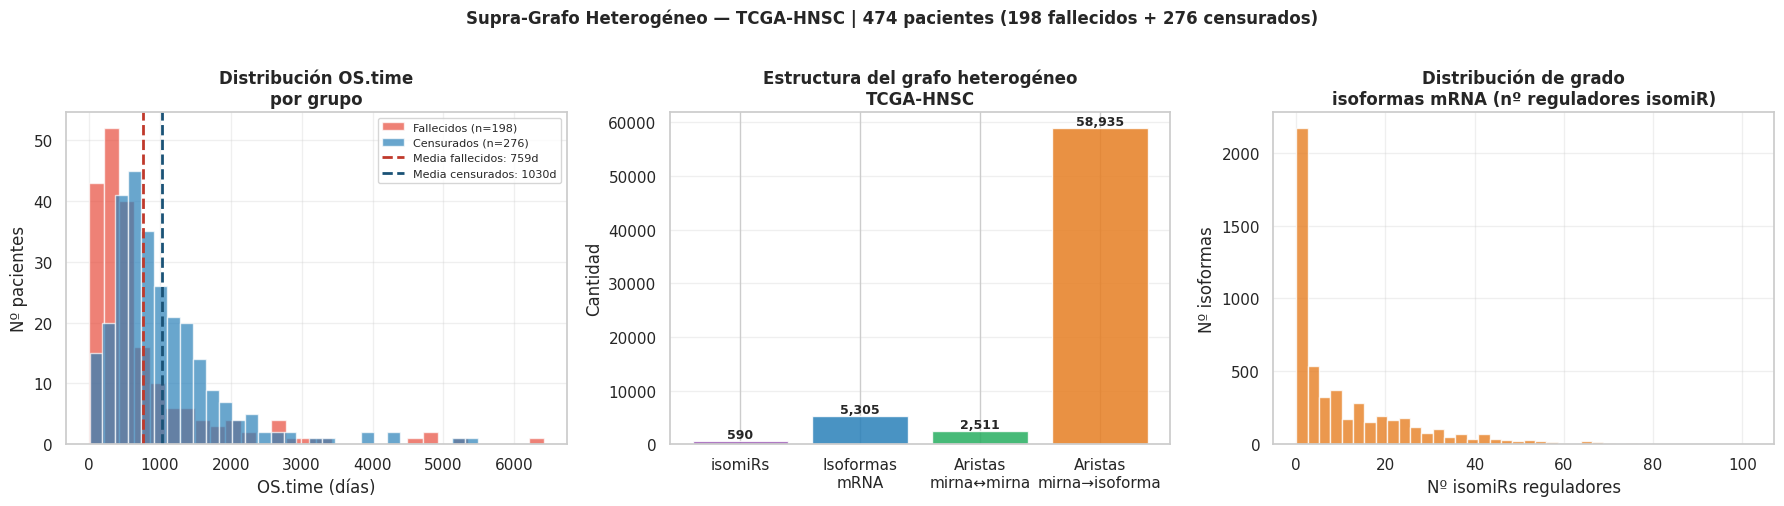

In [ ]:
# VISUALIZACIÓN  resumen del grafo


os_time_np  = graph.os_time.numpy()
os_event_np = graph.os_event.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [0] Distribución OS.time por grupo
axes[0].hist(os_time_np[os_event_np==1], bins=30, alpha=0.7,
             color='#e74c3c', label=f'Fallecidos (n={int(os_event_np.sum())})')
axes[0].hist(os_time_np[os_event_np==0], bins=30, alpha=0.7,
             color='#2980b9', label=f'Censurados (n={int((os_event_np==0).sum())})')
axes[0].axvline(os_time_np[os_event_np==1].mean(), color='#c0392b',
                lw=2, linestyle='--',
                label=f'Media fallecidos: {os_time_np[os_event_np==1].mean():.0f}d')
axes[0].axvline(os_time_np[os_event_np==0].mean(), color='#1a5276',
                lw=2, linestyle='--',
                label=f'Media censurados: {os_time_np[os_event_np==0].mean():.0f}d')
axes[0].set_title('Distribución OS.time\npor grupo', fontweight='bold')
axes[0].set_xlabel('OS.time (días)')
axes[0].set_ylabel('Nº pacientes')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# [1] Estructura del grafo
categorias = ['isomiRs', 'Isoformas\nmRNA', 'Aristas\nmirna↔mirna', 'Aristas\nmirna→isoforma']
valores    = [
    n_mirna, n_isoform,
    ei_mm.shape[1] // 2,
    ei_mi.shape[1]
]
colores = ['#8e44ad', '#2980b9', '#27ae60', '#e67e22']
bars = axes[1].bar(categorias, valores, color=colores, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(valores)*0.01,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Estructura del grafo heterogéneo\nTCGA-HNSC', fontweight='bold')
axes[1].set_ylabel('Cantidad')
axes[1].grid(axis='y', alpha=0.3)

# [2] Distribución grado isoformas (nº reguladores miRNA por isoforma)
axes[2].hist(grado_isoform.numpy(), bins=40, color='#e67e22', alpha=0.8, edgecolor='white')
axes[2].set_title('Distribución de grado\nisoformas mRNA (nº reguladores isomiR)', fontweight='bold')
axes[2].set_xlabel('Nº isomiRs reguladores')
axes[2].set_ylabel('Nº isoformas')
axes[2].grid(alpha=0.3)

plt.suptitle(
    f'Supra-Grafo Heterogéneo  TCGA-HNSC | {n_pats} pacientes '
    f'({int(os_event_np.sum())} fallecidos + {int((os_event_np==0).sum())} censurados)',
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'resumen_supragrafo_hnsc.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 9: Guardado del grafo y ficheros auxiliares

Serializa el objeto `HeteroData` completo como `hetero_graph_all.pt`. Exporta también los DataFrames de aristas en CSV para inspección. El print de cierre documenta la estructura completa del objeto para NB04.

In [ ]:

# GUARDADO


graph_out = PROCESSED_DIR / 'hetero_graph_all.pt'
torch.save(graph, graph_out)

print('═' * 58)
print('OUTPUTS NB03  guardados en:', PROCESSED_DIR)
print('═' * 58)
print(f'  hetero_graph_all.pt        grafo único, {n_pats} pacientes')
print(f'    mirna.x                 : {graph["mirna"].x.shape}')
print(f'    isoform.x               : {graph["isoform"].x.shape}')
print(f'    aristas mirna↔mirna     : {ei_mm.shape[1]//2} pares')
print(f'    aristas mirna→isoforma  : {ei_mi.shape[1]}')
print(f'    os_time                 : {graph.os_time.shape}')
print(f'    os_event                : {graph.os_event.shape}')
print(f'  mirna_mirna_edges.csv      {len(mirna_mirna_edges)} pares')
print(f'  mirna_isoform_edges.csv    {len(mirna_isoform_edges)} pares')
print(f'  resumen_supragrafo_hnsc.png')
print()
print('Estructura HeteroData para NB04:')
print('  graph["mirna"].x                              [n_mirna x n_pacientes]')
print('  graph["isoform"].x                            [n_isoformas x n_pacientes]')
print('  graph["mirna","coexpresses","mirna"].edge_index')
print('  graph["mirna","coexpresses","mirna"].edge_attr  (Spearman r)')
print('  graph["mirna","represses","isoform"].edge_index')
print('  graph["mirna","represses","isoform"].edge_attr  (context++ score)')
print('  graph.os_time    [n_pacientes]  float32')
print('  graph.os_event   [n_pacientes]  float32  (1=fallecido, 0=censurado)')
print('  graph.barcodes   lista de barcodes TCGA')
print('  graph["mirna"].node_ids    lista de MIMATs')
print('  graph["isoform"].node_ids  lista de isoforma IDs')
print()
print('PRÓXIMO PASO: NB04  SupraGraphNet interpretabilidad.')

══════════════════════════════════════════════════════════
OUTPUTS NB03 — guardados en: /content/drive/MyDrive/TFM/data/processed_hnsc
══════════════════════════════════════════════════════════
  hetero_graph_all.pt       — grafo único, 474 pacientes
    mirna.x                 : torch.Size([590, 474])
    isoform.x               : torch.Size([5305, 474])
    aristas mirna↔mirna     : 2511 pares
    aristas mirna→isoforma  : 58935
    os_time                 : torch.Size([474])
    os_event                : torch.Size([474])
  mirna_mirna_edges.csv     — 2511 pares
  mirna_isoform_edges.csv   — 58935 pares
  resumen_supragrafo_hnsc.png

Estructura HeteroData para NB04:
  graph["mirna"].x                              [n_mirna x n_pacientes]
  graph["isoform"].x                            [n_isoformas x n_pacientes]
  graph["mirna","coexpresses","mirna"].edge_index
  graph["mirna","coexpresses","mirna"].edge_attr  (Spearman r)
  graph["mirna","represses","isoform"].edge_index
  graph["mi

## Resumen del grafo heterogéneo

| Elemento | Valor |
|---|---|
| Nodos isomiRs miRNA | 590 |
| Nodos isoformas mRNA | 5.305 |
| Pacientes (features por nodo) | 474 (198 fallecidos, 276 censurados) |
| Aristas isomiR↔isomiR (`coexpresses`) | 2.511 pares · Spearman \|r\|≥0.55 · grado medio 8.5 |
| Aristas isomiR→isoforma (`represses`) | 58.935 · context++ score < 0 |
| isomiRs aislados (sin co-expresión) | 179 |
| Isoformas sin regulador TargetScan | 1.620 |

**Ficheros exportados:** `hetero_graph_all.pt`, `mirna_mirna_edges.csv` (2.511 filas), `mirna_isoform_edges.csv` (58.935 filas), `resumen_supragrafo_hnsc.png`

**Siguiente:** NB04: SupraGraphNet: entrenamiento, Cox Loss, C-index e interpretabilidad.